In [46]:
# Car Price Prediction with Machine Learning

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


# Load the dataset

In [47]:
# Load the dataset
df = pd.read_csv("cardekho_dataset.csv")

# Display the first 5 rows
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


# Data Cleaning

In [48]:
#Shape - The size of the Row and Column 
df.shape

(15411, 14)

In [49]:
#column names
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [50]:
#Data types
print(df.dtypes)

Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object


In [51]:
#Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [52]:
#Checking for Missing Values
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [53]:
# Checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [54]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check the remaining columns
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [55]:
df.head(2)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7,796,46.3,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.9,1197,82.0,5,550000


# Clean categorical values

In [56]:
categorical_columns = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


brand:
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche']

model:
['Alto' 'Grand' 'i20' 'Ecosport' 'Wagon R' 'i10' 'Venue' 'Swift' 'Verna'
 'Duster' 'Cooper' 'Ciaz' 'C-Class' 'Innova' 'Baleno' 'Swift Dzire'
 'Vento' 'Creta' 'City' 'Bolero']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

fuel_type:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

transmission_type:
['Manual' 'Automatic']


In [57]:
# Cleaning categorical columns
for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.lower()

print("Categorical values cleaned successfully.")

Categorical values cleaned successfully.


# Clean numerical columns

In [58]:
# Inspecting numerical columns
for column in ["vehicle_age", "km_driven", "mileage", "engine", "max_power", "seats", "selling_price"]:
    print(f"\n{column}:")
    print(df[column].head())


vehicle_age:
0     9
1     5
2    11
3     9
4     6
Name: vehicle_age, dtype: int64

km_driven:
0    120000
1     20000
2     60000
3     37000
4     30000
Name: km_driven, dtype: int64

mileage:
0    19.70
1    18.90
2    17.00
3    20.92
4    22.77
Name: mileage, dtype: float64

engine:
0     796
1    1197
2    1197
3     998
4    1498
Name: engine, dtype: int64

max_power:
0    46.30
1    82.00
2    80.00
3    67.10
4    98.59
Name: max_power, dtype: float64

seats:
0    5
1    5
2    5
3    5
4    5
Name: seats, dtype: int64

selling_price:
0    120000
1    550000
2    215000
3    226000
4    570000
Name: selling_price, dtype: int64


In [59]:
# Dataset summary
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


# Feature engineering: calculate **car age** from the year column; extract brand from the car name column?

In [60]:
df["Brand_Extracted"] = df["car_name"].str.split().str[0]

# Displaying the original car name and extracted brand
print("Extracted Brand:")
display(df[["car_name", "Brand_Extracted"]].head(10))

print("\nVehicle Age:")
display(df[["vehicle_age"]].head(10))


# 3. Comparing the existing brand with our extracted brand

print("\nExisting vs Extracted Brand:")
display(
    df[["car_name", "brand", "Brand_Extracted"]].head(10)
)

Extracted Brand:


,car_name,Brand_Extracted
0,Maruti Alto,Maruti
1,Hyundai Grand,Hyundai
2,Hyundai i20,Hyundai
3,Maruti Alto,Maruti
4,Ford Ecosport,Ford
5,Maruti Wagon R,Maruti
6,Hyundai i10,Hyundai
7,Maruti Wagon R,Maruti
8,Hyundai Venue,Hyundai
9,Maruti Swift,Maruti



Vehicle Age:


,vehicle_age
0,9
1,5
2,11
3,9
4,6
5,8
6,8
7,3
8,2
9,4



Existing vs Extracted Brand:


,car_name,brand,Brand_Extracted
0,Maruti Alto,maruti,Maruti
1,Hyundai Grand,hyundai,Hyundai
2,Hyundai i20,hyundai,Hyundai
3,Maruti Alto,maruti,Maruti
4,Ford Ecosport,ford,Ford
5,Maruti Wagon R,maruti,Maruti
6,Hyundai i10,hyundai,Hyundai
7,Maruti Wagon R,maruti,Maruti
8,Hyundai Venue,hyundai,Hyundai
9,Maruti Swift,maruti,Maruti


In [61]:
# Check the number of unique brands
print("Existing brands:", df["brand"].nunique())
print("Extracted brands:", df["Brand_Extracted"].nunique())

Existing brands: 31
Extracted brands: 32


In [62]:
# Display the most common extracted brands
df["Brand_Extracted"].value_counts().head(15)

Brand_Extracted
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Jaguar             59
Name: count, dtype: int64

# EDA: Selling Price Distribution

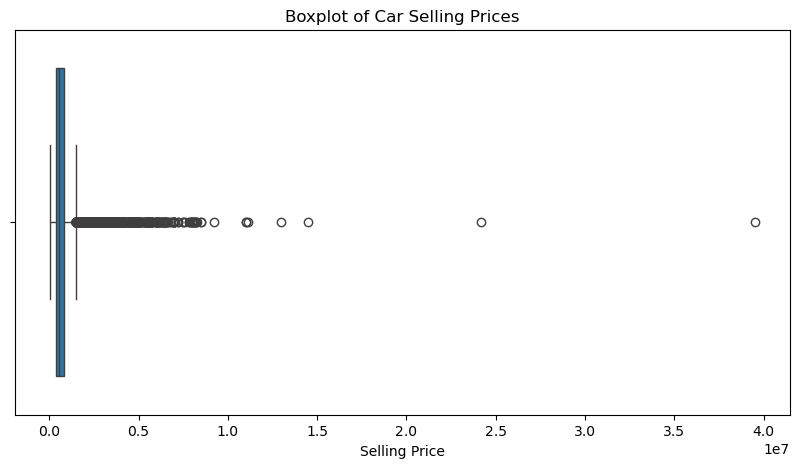

In [63]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["selling_price"])

plt.title("Boxplot of Car Selling Prices")
plt.xlabel("Selling Price")

plt.show()

# Price vs Fuel Type

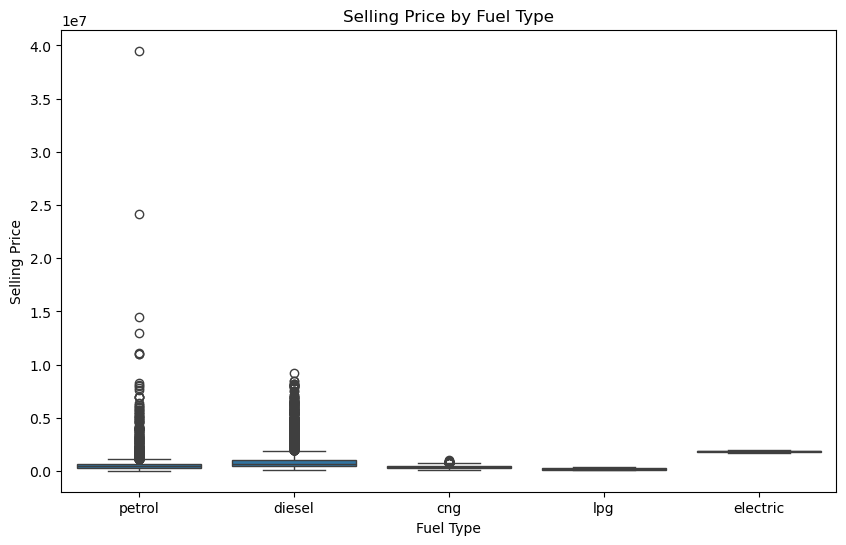

In [64]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="fuel_type",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

# Price vs Car Age

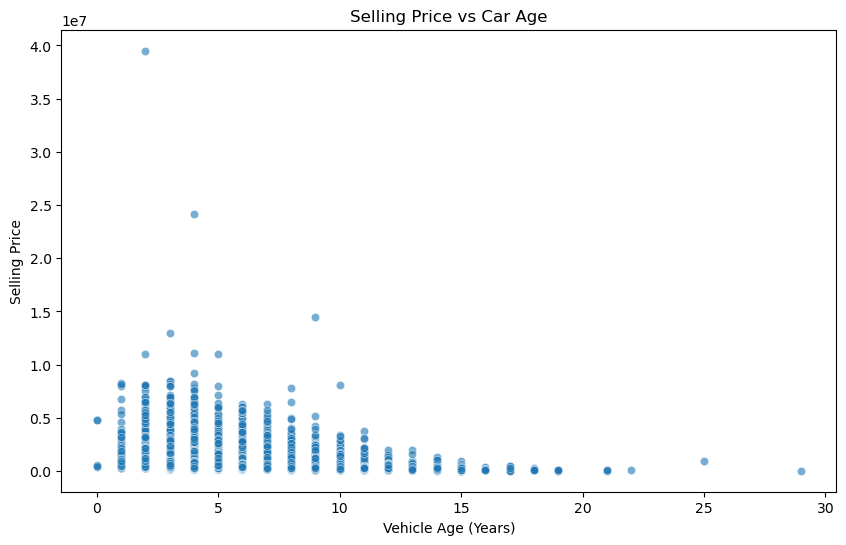

In [65]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="selling_price",
    alpha=0.6
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Selling Price")

plt.show()

# Correlation Heatmap

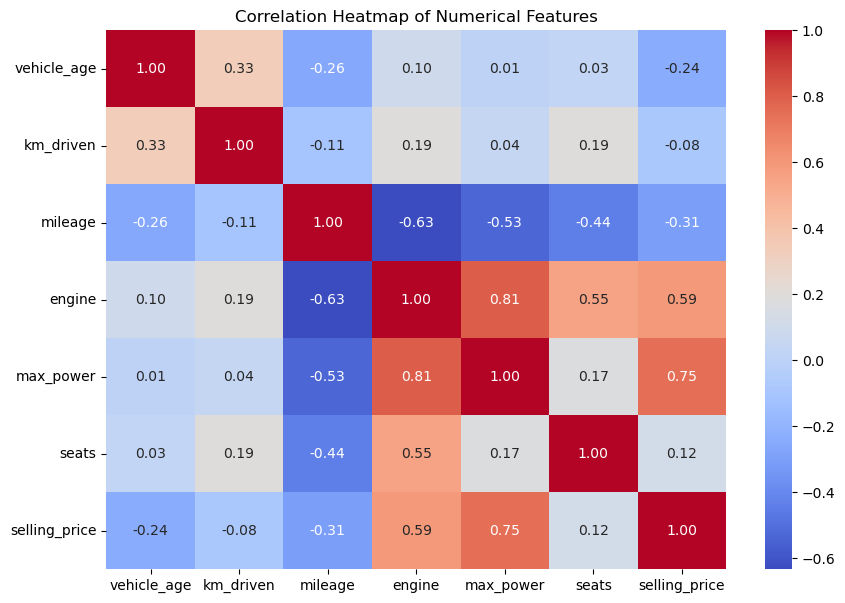

In [66]:
# Select numerical columns
numerical_columns = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "selling_price"
]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

# Encode categorical variables (One-Hot Encoding or Label Encoding

In [67]:
features = [
    "brand",
    "vehicle_age",
    "km_driven",
    "seller_type",
    "fuel_type",
    "transmission_type",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Input features
X = df[features]

# Target variable
y = df["selling_price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (15411, 10)
Target shape: (15411,)


In [69]:
# Categorical features
categorical_features = [
    "brand",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

# Numerical features
numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# One-Hot Encoding for categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("One-Hot Encoder created successfully.")

One-Hot Encoder created successfully.


# Train/Test Split

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (12328, 10)
Testing features: (3083, 10)
Training target: (12328,)
Testing target: (3083,)


# Train Model 1 — Linear Regression

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [74]:
# Make predictions using Linear Regression
linear_predictions = linear_model.predict(X_test)

print("First 10 predictions:")
print(linear_predictions[:10])

First 10 predictions:
[ -80605.96381532  641142.74042632  594833.77767796 1392507.05793957
 -334985.35610182 1033789.95647036  334826.74866247  310690.2490361
  620746.26736856 1844431.78084949]


# Train Model 2 — Random Forest Regressor

In [75]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [76]:
# Make predictions using Random Forest
rf_predictions = random_forest_model.predict(X_test)

print("First 10 predictions:")
print(rf_predictions[:10])

First 10 predictions:
[ 240865.          623615.          643055.         1207970.
  179597.91666667  434360.          474366.66666667  299259.04761905
  371080.         1224917.5       ]


# Evaluate Both Models

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression 

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)


# Random Forest 

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)


# Display results

print("LINEAR REGRESSION")
print("-----------------")
print(f"MAE : {linear_mae:,.2f}")
print(f"RMSE: {linear_rmse:,.2f}")
print(f"R²  : {linear_r2:.4f}")

print("\nRANDOM FOREST")
print("-------------")
print(f"MAE : {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R²  : {rf_r2:.4f}")

LINEAR REGRESSION
-----------------
MAE : 270,497.31
RMSE: 491,948.74
R²  : 0.6785

RANDOM FOREST
-------------
MAE : 101,293.22
RMSE: 225,180.61
R²  : 0.9326


## Model Comparison Table

In [78]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R² Score": [
        linear_r2,
        rf_r2
    ]
})

results.round(2)

,Model,MAE,RMSE,R² Score
0,Linear Regression,270497.31,491948.74,0.68
1,Random Forest,101293.22,225180.61,0.93


# Best Model

In [80]:
# Get the trained Random Forest model
rf_model = random_forest_model.named_steps["model"]

# Get the fitted preprocessor
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]

In [81]:
# Get feature names after One-Hot Encoding
encoded_feature_names = (
    fitted_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

# Combine encoded categorical features with numerical features
feature_names = list(encoded_feature_names) + numerical_features

print("Number of features:", len(feature_names))

Number of features: 46


In [83]:
# Get feature importance from Random Forest
feature_importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(2)

,Feature,Importance
44,max_power,0.657946
40,vehicle_age,0.129769


# Feature Importance Chart

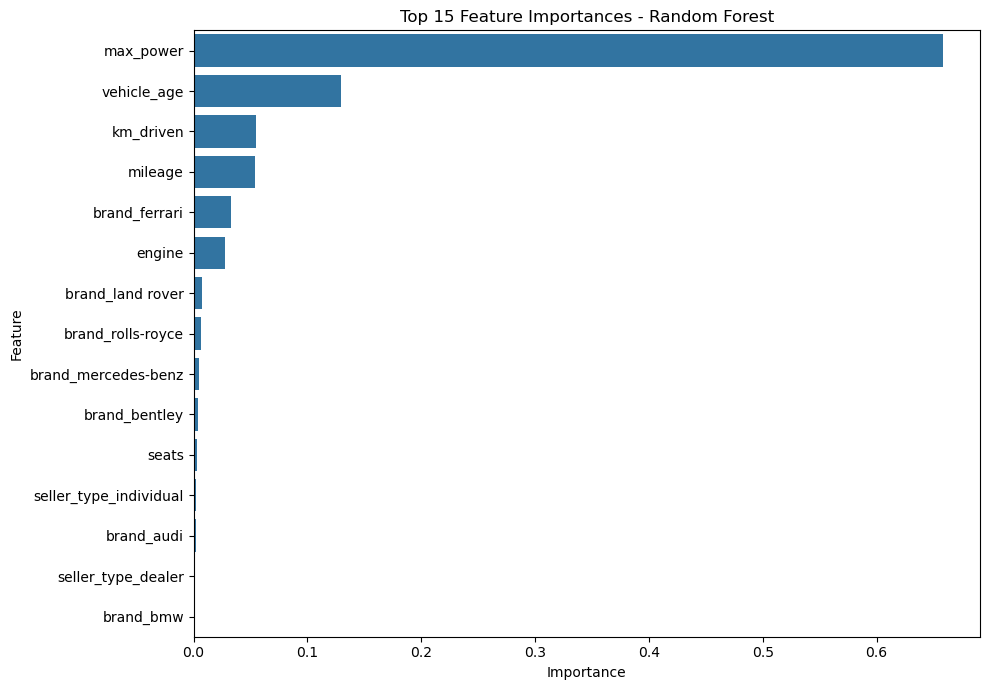

In [84]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Actual vs Predicted Prices

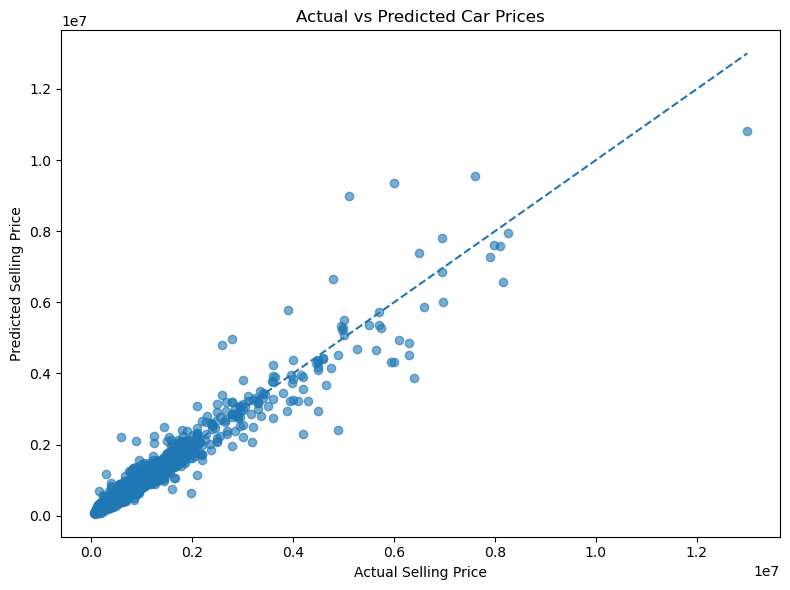

In [86]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

# Reference line
min_price = min(y_test.min(), rf_predictions.min())
max_price = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.tight_layout()
plt.show()

# Saving the Random Forest model

In [87]:
import joblib

# Save the trained Random Forest pipeline
joblib.dump(random_forest_model, "car_price_model.pkl")

print("Model saved successfully as car_price_model.pkl")

Model saved successfully as car_price_model.pkl


In [88]:
import os

print(os.path.abspath("car_price_model.pkl"))
print("File exists:", os.path.exists("car_price_model.pkl"))

C:\Users\t50057060\car_price_model.pkl
File exists: True


In [91]:
#Testing the model
import joblib
import pandas as pd

# Load the saved model
model = joblib.load(r"C:\Users\t50057060\car_price_model.pkl")

print("Model loaded successfully!")
print("Model type:", type(model))

# Create a test vehicle
test_car = pd.DataFrame([{
    "brand": "Toyota",
    "vehicle_age": 5,
    "km_driven": 45000,
    "seller_type": "Individual",
    "fuel_type": "Petrol",
    "transmission_type": "Manual",
    "mileage": 18.5,
    "engine": 1197,
    "max_power": 82,
    "seats": 5
}])

# Make prediction
prediction = model.predict(test_car)

print("Predicted price:", prediction[0])

Model loaded successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>
Predicted price: 518512.8571428571
